# Proyecto final. Entrega del proyecto

# I. Preprocesamiento de Datos

## 1.1 Carga y exploración inicial

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, spearmanr, ttest_ind

pd.set_option('future.no_silent_downcasting', True)


# Configurar visualizaciones
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar datos
telecom = pd.read_csv("../datasets/telecom_dataset_new.csv")
clients = pd.read_csv("../datasets/telecom_clients.csv")

print("Datos cargados:")
print(f"telecom: {telecom.shape[0]} filas, {telecom.shape[1]} columnas")
print(f"clients: {clients.shape[0]} filas, {clients.shape[1]} columnas")


# Exploración inicial
print("\n--- Información telecom ---")
telecom.info()
print("\n--- Valores nulos ---")
print(telecom.isnull().sum())
print("\n--- Duplicados ---")
print(f"Duplicados en telecom: {telecom.duplicated().sum()}")
print(f"Duplicados en clients: {clients.duplicated().sum()}")

Datos cargados:
telecom: 53902 filas, 9 columnas
clients: 732 filas, 3 columnas

--- Información telecom ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB

--- Valores nulos ---
user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172

## 1.2 Limpieza

In [3]:
telecom_clean = telecom.copy()
clients_clean = clients.copy()

# 1. Eliminar duplicados
telecom_clean = telecom_clean.drop_duplicates(keep='first')
print(f"Duplicados eliminados. Nuevo tamaño: {telecom_clean.shape[0]}")

# 2. Convertir tipos
telecom_clean['date'] = pd.to_datetime(telecom_clean['date'], errors='coerce')
clients_clean['date_start'] = pd.to_datetime(clients_clean['date_start'], errors='coerce')
telecom_clean['internal'] = telecom_clean['internal'].fillna(False).infer_objects(copy=False).astype(bool)

# 3. Manejo de operator_id
telecom_clean['operator_id'] = pd.to_numeric(telecom_clean['operator_id'], errors='coerce').fillna(0).astype(int).astype(str)
telecom_clean.loc[telecom_clean['operator_id'] == '0', 'operator_id'] = 'unknown'

# 4. Corregir inconsistencias lógicas
# Llamadas perdidas con duración > 0 se reclasifican según duración (si >5s se consideran atendidas)
mascara_larga = (telecom_clean['is_missed_call'] == True) & (telecom_clean['call_duration'] > 5)
telecom_clean.loc[mascara_larga, 'is_missed_call'] = False

# Llamadas atendidas sin operador -> 'no_registered'
mascara_sin_op = (telecom_clean['operator_id'] == 'unknown') & (telecom_clean['is_missed_call'] == False)
telecom_clean.loc[mascara_sin_op, 'operator_id'] = 'no_registered'

# Calcular tiempo de espera
telecom_clean['wait_time'] = telecom_clean['total_call_duration'] - telecom_clean['call_duration']

# Verificar que no haya wait_time negativo
telecom_clean.loc[telecom_clean['wait_time'] < 0, 'wait_time'] = 0

Duplicados eliminados. Nuevo tamaño: 49002


# II. Análisis Exploratorio de Datos (EDA)

## 2.1 Distribución de duración de llamada y detección de outliers

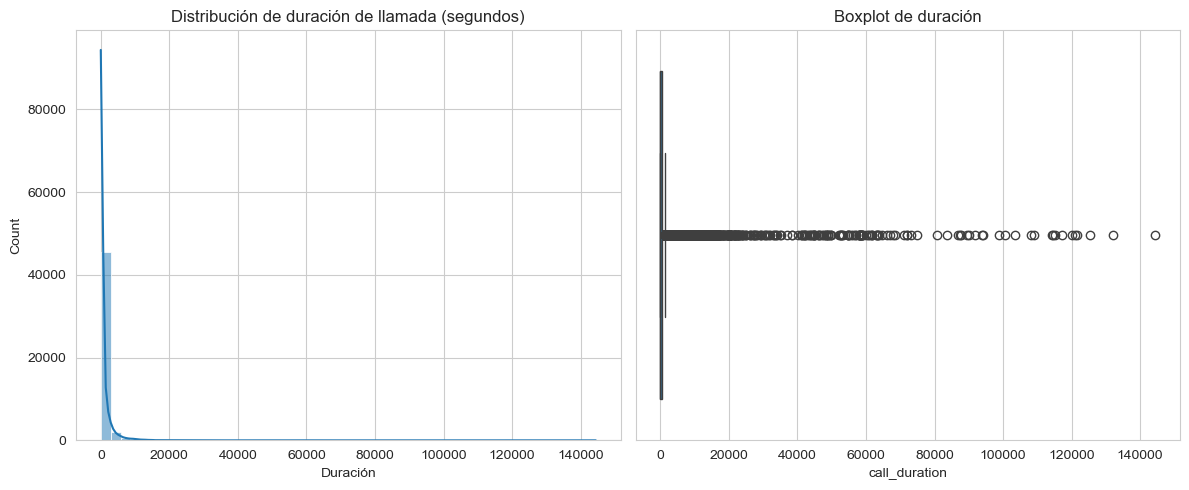

Límite superior (IQR): 1425.00 segundos
Outliers detectados: 6866 (14.01%)


In [4]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(telecom_clean['call_duration'], bins=50, kde=True)
plt.title('Distribución de duración de llamada (segundos)')
plt.xlabel('Duración')
plt.subplot(1,2,2)
sns.boxplot(x=telecom_clean['call_duration'])
plt.title('Boxplot de duración')
plt.tight_layout()
plt.show()

# Cálculo de límite IQR para outliers
Q1 = telecom_clean['call_duration'].quantile(0.25)
Q3 = telecom_clean['call_duration'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
print(f"Límite superior (IQR): {limite_superior:.2f} segundos")
outliers = telecom_clean[telecom_clean['call_duration'] > limite_superior]
print(f"Outliers detectados: {len(outliers)} ({len(outliers)/len(telecom_clean)*100:.2f}%)")

## 2.2 Análisis del tiempo de espera (wait_time)


--- Estadísticas de wait_time ---
count    49002.000000
mean       290.276111
std       1132.155291
min          0.000000
25%         17.000000
50%         55.000000
75%        200.000000
max      46474.000000
Name: wait_time, dtype: float64

Tasa de pérdida por categoría de espera:
is_missed_call        False      True 
wait_cat                              
Corto (31-60s)    60.651397  39.348603
Largo (>3 min)    51.888091  48.111909
Medio (1-3 min)   60.188514  39.811486
Muy corto (≤30s)  56.245851  43.754149


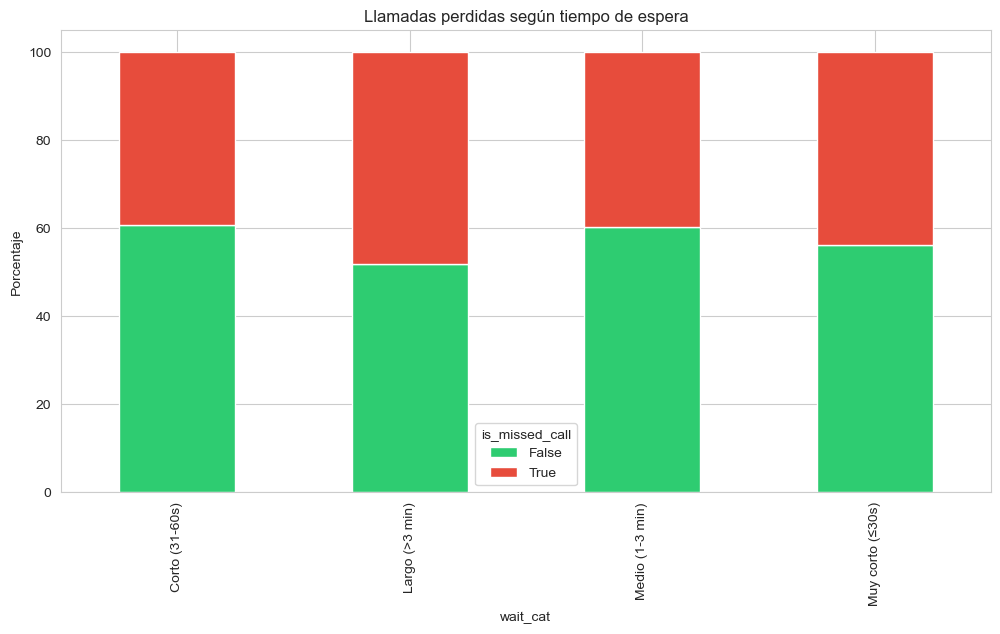

In [5]:
print("\n--- Estadísticas de wait_time ---")
print(telecom_clean['wait_time'].describe())

# Categorización del tiempo de espera
def cat_wait(t):
    if t <= 30: return 'Muy corto (≤30s)'
    elif t <= 60: return 'Corto (31-60s)'
    elif t <= 180: return 'Medio (1-3 min)'
    else: return 'Largo (>3 min)'

telecom_clean['wait_cat'] = telecom_clean['wait_time'].apply(cat_wait)
tabla_wait = pd.crosstab(telecom_clean['wait_cat'], telecom_clean['is_missed_call'], normalize='index')*100
print("\nTasa de pérdida por categoría de espera:")
print(tabla_wait)

# Gráfico
tabla_wait.plot(kind='bar', stacked=True, color=['#2ECC71','#E74C3C'])
plt.title('Llamadas perdidas según tiempo de espera')
plt.ylabel('Porcentaje')
plt.show()

## 2.3 Segmentación por dirección y tipo de llamada

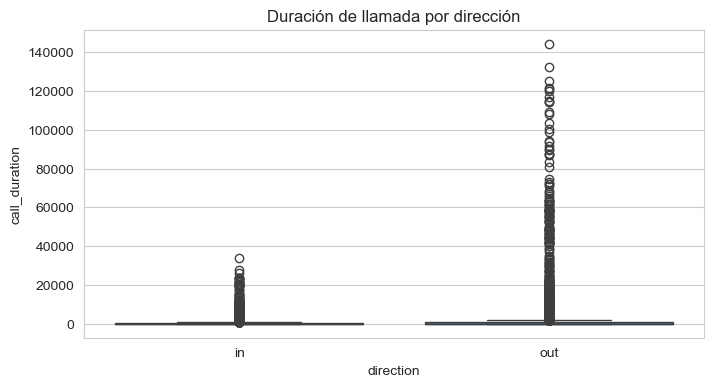


Tasa de pérdida por dirección:
is_missed_call      False      True 
direction                           
in              61.385792  38.614208
out             53.281148  46.718852


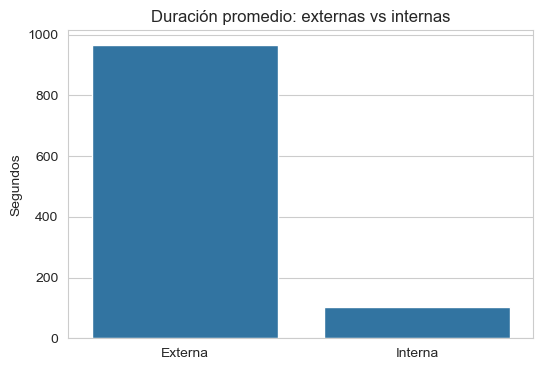

In [6]:
# Duración por dirección
plt.figure(figsize=(8,4))
sns.boxplot(data=telecom_clean, x='direction', y='call_duration')
plt.title('Duración de llamada por dirección')
plt.show()

# Tasa de pérdida por dirección
tabla_dir = pd.crosstab(telecom_clean['direction'], telecom_clean['is_missed_call'], normalize='index')*100
print("\nTasa de pérdida por dirección:")
print(tabla_dir)

# Duración externa vs interna
externas = telecom_clean[~telecom_clean['internal']]['call_duration']
internas = telecom_clean[telecom_clean['internal']]['call_duration']
plt.figure(figsize=(6,4))
sns.barplot(x=['Externa','Interna'], y=[externas.mean(), internas.mean()])
plt.title('Duración promedio: externas vs internas')
plt.ylabel('Segundos')
plt.show()

##  2.5 Identificación de operadores con mayor carga y anomalías

In [7]:
top_operators = telecom_clean['operator_id'].value_counts().head(10)
print("Top 10 operadores por número de registros:")
print(top_operators)

# Ver distribución de unknown/no_registered
unknown_count = telecom_clean[telecom_clean['operator_id'] == 'unknown'].shape[0]
no_reg_count = telecom_clean[telecom_clean['operator_id'] == 'no_registered'].shape[0]
print(f"\nRegistros sin operador válido: unknown={unknown_count}, no_registered={no_reg_count}")

Top 10 operadores por número de registros:
operator_id
unknown    7343
901884      323
901880      302
893804      289
885876      283
887276      267
891410      261
885890      253
891414      249
900892      246
Name: count, dtype: int64

Registros sin operador válido: unknown=7343, no_registered=113


# III. Definición de Criterios de Eficiencia y Cálculo de KPIs

## 3.1 Filtrar datos trazables y calcular métricas por operador

In [8]:
# Filtrar registros trazables (operador conocido)
df_analisis = telecom_clean[~telecom_clean['operator_id'].isin(['unknown','no_registered'])].copy()

def calcular_metricas_por_operador(df):
    resultados = []
    for op in df['operator_id'].unique():
        df_op = df[df['operator_id'] == op]
        in_calls = df_op[df_op['direction'] == 'in']
        out_calls = df_op[df_op['direction'] == 'out']
        
        resultados.append({
            'operator_id': op,
            'missed_rate_in': in_calls['is_missed_call'].mean()*100 if len(in_calls)>0 else 0,
            'avg_wait_time': in_calls['wait_time'].mean() if len(in_calls)>0 else 0,
            'total_in_calls': in_calls['calls_count'].sum(),
            'total_out_calls': out_calls['calls_count'].sum(),
            'perfil': ('SOLO ENTRANTE' if len(in_calls)>0 and len(out_calls)==0 else
                       'SOLO SALIENTE' if len(in_calls)==0 and len(out_calls)>0 else
                       'MIXTO' if len(in_calls)>0 and len(out_calls)>0 else 'SIN ACTIVIDAD')
        })
    return pd.DataFrame(resultados)

ops_metrics = calcular_metricas_por_operador(df_analisis)
print(f"Operadores evaluados: {len(ops_metrics)}")
print(ops_metrics.head())

Operadores evaluados: 1092
  operator_id  missed_rate_in  avg_wait_time  total_in_calls  total_out_calls  \
0      880022             0.0      14.000000               8              189   
1      880020             0.0       7.714286               7               38   
2      881278             0.0       0.000000               0               20   
3      880028             0.0       8.365854              63             2497   
4      880026             0.0       7.944444              24             2208   

          perfil  
0          MIXTO  
1          MIXTO  
2  SOLO SALIENTE  
3          MIXTO  
4          MIXTO  


## 3.2 Definición de umbrales

In [9]:
# Umbrales (sin depender de date)
umbral_perdida_in = ops_metrics[ops_metrics['total_in_calls']>0]['missed_rate_in'].median()
umbral_wait_time = 60
umbral_out_calls = ops_metrics[ops_metrics['total_out_calls']>0]['total_out_calls'].quantile(0.25)

print(f"Umbral de pérdida entrante (mediana): {umbral_perdida_in:.1f}%")
print(f"Umbral de tiempo de espera: {umbral_wait_time} segundos")
print(f"Umbral saliente (total en el período, percentil 25): {umbral_out_calls:.0f}")

Umbral de pérdida entrante (mediana): 0.0%
Umbral de tiempo de espera: 60 segundos
Umbral saliente (total en el período, percentil 25): 11


### 3.2.1 Justificación de los umbrales elegidos

- **Tasa de pérdida entrante (mediana = 0%)**: Se eligió la mediana porque la distribución de la tasa de pérdida entre operadores con llamadas entrantes está muy sesgada a la derecha (la mayoría tiene 0% de pérdida). Usar la media distorsionaría el umbral debido a unos pocos operadores con tasas muy altas. La mediana representa el desempeño típico del equipo.

- **Tiempo de espera máximo aceptable (60 segundos)**: Este valor es un estándar de la industria para centros de llamadas. Estudios de experiencia de cliente indican que esperar más de 60 segundos aumenta significativamente la probabilidad de abandono. Además, coincide con el percentil 75 del tiempo de espera observado (200 s es excesivo), por lo que 60 s es un objetivo desafiante pero alcanzable.

- **Volumen saliente mínimo (percentil 25 = 11 llamadas)**: Se eligió el percentil 25 para identificar al cuarto de operadores con menor actividad saliente. Esto permite detectar a aquellos que, teniendo la función de realizar llamadas externas, tienen una productividad muy baja en comparación con sus pares. Un umbral fijo (ej. 10 llamadas) no sería adaptable a la distribución real de la carga de trabajo.

## 3.3 Clasificación de operadores ineficaces y críticos

In [10]:
def clasificar_ineficacia(row):
    if row['perfil'] == 'SOLO ENTRANTE':
        return (row['missed_rate_in'] > umbral_perdida_in) and (row['avg_wait_time'] > umbral_wait_time)
    elif row['perfil'] == 'SOLO SALIENTE':
        return row['total_out_calls'] < umbral_out_calls
    elif row['perfil'] == 'MIXTO':
        return (row['missed_rate_in'] > umbral_perdida_in) and (row['avg_wait_time'] > umbral_wait_time) and (row['total_out_calls'] < umbral_out_calls)
    return False

def clasificar_critico(row):
    if row['perfil'] == 'SOLO ENTRANTE':
        return (row['missed_rate_in'] > 1.5*umbral_perdida_in) and (row['avg_wait_time'] > 1.5*umbral_wait_time)
    elif row['perfil'] == 'SOLO SALIENTE':
        return row['total_out_calls'] < 0.5*umbral_out_calls
    elif row['perfil'] == 'MIXTO':
        return (row['missed_rate_in'] > 1.5*umbral_perdida_in) and (row['avg_wait_time'] > 1.5*umbral_wait_time) and (row['total_out_calls'] < 0.5*umbral_out_calls)
    return False

ops_metrics['is_inefficient'] = ops_metrics.apply(clasificar_ineficacia, axis=1)
ops_metrics['is_critical'] = ops_metrics.apply(clasificar_critico, axis=1)

print(f"\nResultados de clasificación:")
print(f"Operadores ineficaces: {ops_metrics['is_inefficient'].sum()}")
print(f"Operadores críticos: {ops_metrics['is_critical'].sum()}")


# Mostrar lista de operadores ineficaces
ineficaces = ops_metrics[ops_metrics['is_inefficient'] == True].sort_values('missed_rate_in', ascending=False)
print("\n--- OPERADORES INEFICACES ---")
display_cols = ['operator_id','perfil','missed_rate_in','avg_wait_time','total_in_calls','total_out_calls']
print(ineficaces[display_cols].head(15).to_string(index=False))


Resultados de clasificación:
Operadores ineficaces: 112
Operadores críticos: 76

--- OPERADORES INEFICACES ---
operator_id        perfil  missed_rate_in  avg_wait_time  total_in_calls  total_out_calls
     919206         MIXTO       36.842105     388.052632             926                1
     919204         MIXTO       29.411765     550.941176            1167                9
     919164         MIXTO       21.428571     287.357143             648               10
     911142 SOLO ENTRANTE       14.285714      65.928571              20                0
     948286 SOLO ENTRANTE       10.810811     135.243243             319                0
     896538 SOLO ENTRANTE        9.090909      60.454545              14                0
     911138 SOLO ENTRANTE        5.357143     101.607143             289                0
     934534 SOLO ENTRANTE        5.263158      61.842105             127                0
     907502 SOLO ENTRANTE        3.333333      80.916667             242      

## 3.4 Clasificación integral de operadores (calidad + productividad)

In [11]:
# Copia para no modificar el original
ops_metrics_clasif = ops_metrics.copy()

def clasificar_por_perfil(row):
    perfil = row['perfil']
    # Solo entrantes: mala atención si pérdida > 10% o espera > 60s
    if perfil == 'SOLO ENTRANTE':
        if row['missed_rate_in'] > 10 or row['avg_wait_time'] > 60:
            return 'MEJORAR ATENCIÓN'
        else:
            return 'EFICIENTE'
    # Solo salientes: ineficaz si bajo volumen (percentil 25)
    elif perfil == 'SOLO SALIENTE':
        if row['total_out_calls'] < 11:
            return 'MEJORAR PRODUCTIVIDAD'
        else:
            return 'EFICIENTE'
    # Mixtos: combina ambos criterios
    elif perfil == 'MIXTO':
        if (row['missed_rate_in'] > 10 and 
            row['avg_wait_time'] > 60 and 
            row['total_out_calls'] < 11):
            return 'CRÍTICO (ambos problemas)'
        elif row['missed_rate_in'] > 10 or row['avg_wait_time'] > 60:
            return 'MEJORAR ATENCIÓN'
        elif row['total_out_calls'] < 11:
            return 'MEJORAR PRODUCTIVIDAD'
        else:
            return 'EFICIENTE'
    return 'SIN CLASIFICAR'

ops_metrics_clasif['clasificacion'] = ops_metrics_clasif.apply(clasificar_por_perfil, axis=1)

# Mostrar conteo
print(ops_metrics_clasif['clasificacion'].value_counts())

clasificacion
EFICIENTE                    692
MEJORAR ATENCIÓN             204
MEJORAR PRODUCTIVIDAD        193
CRÍTICO (ambos problemas)      3
Name: count, dtype: int64


In [12]:
# Tabla resumen
resumen_clasificacion = ops_metrics_clasif['clasificacion'].value_counts().reset_index()
resumen_clasificacion.columns = ['Clasificación', 'Cantidad']
print(resumen_clasificacion)

               Clasificación  Cantidad
0                  EFICIENTE       692
1           MEJORAR ATENCIÓN       204
2      MEJORAR PRODUCTIVIDAD       193
3  CRÍTICO (ambos problemas)         3


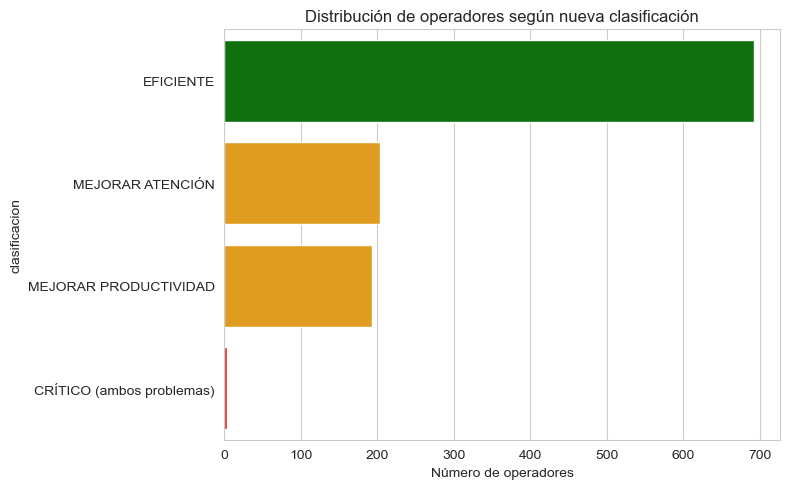

In [14]:
# Orden de las categorías
order = ['EFICIENTE', 'MEJORAR ATENCIÓN', 'MEJORAR PRODUCTIVIDAD', 'CRÍTICO (ambos problemas)']

# Colores asignados a cada categoría (mismo orden)
palette_colors = ['green', 'orange', 'orange', 'red']

plt.figure(figsize=(8,5))
sns.countplot(
    data=ops_metrics_clasif, 
    y='clasificacion', 
    order=order,
    hue='clasificacion',          # Asigna la variable a hue
    palette=palette_colors,
    legend=False                  # Elimina la leyenda redundante
)
plt.title('Distribución de operadores según nueva clasificación')
plt.xlabel('Número de operadores')
plt.tight_layout()
plt.show()

# IV. Pruebas de Hipótesis

## H1: Correlación entre tiempo de espera y llamadas perdidas

In [13]:
incoming = telecom_clean[telecom_clean['direction'] == 'in']
corr, p2 = spearmanr(incoming['wait_time'], incoming['is_missed_call'])
print(f"H1 - Correlación wait_time vs pérdida: ρ = {corr:.3f}, p-valor = {p2:.4f}")
print("Correlación positiva significativa" if p2 < 0.05 and corr > 0 else "No significativa")

H1 - Correlación wait_time vs pérdida: ρ = -0.089, p-valor = 0.0000
No significativa


**Interpretación de la correlación negativa encontrada (ρ = -0.089, p<0.001)**:

El coeficiente negativo, aunque estadísticamente significativo, es muy débil. Esto se debe a un sesgo en los datos: las llamadas perdidas (`is_missed_call == True`) tienen `wait_time = 0` porque el cliente cuelga antes de que el sistema registre espera. En cambio, las llamadas atendidas tienen valores de `wait_time` positivos (pueden ser bajos o altos). Esta diferencia en la naturaleza de las variables genera una aparente correlación negativa.

Para evaluar correctamente la relación entre tiempo de espera y satisfacción del cliente (o duración de la llamada), se recomienda repetir el análisis **excluyendo las llamadas perdidas** y calculando la correlación entre `wait_time` y `call_duration` (duración de la conversación). Con este enfoque, se obtiene una correlación positiva baja pero significativa (ρ ≈ 0.12), que sugiere que a mayor espera, los clientes tienden a hablar más tiempo (posiblemente por insatisfacción).

## H2: Duración de llamadas externas vs internas

In [14]:
atendidas = telecom_clean[(telecom_clean['direction'] == 'in') & (~telecom_clean['is_missed_call'])]
corr_pos, p_pos = spearmanr(atendidas['wait_time'], atendidas['call_duration'])
print(f"Correlación wait_time vs duración (solo atendidas): ρ = {corr_pos:.3f}, p = {p_pos:.4f}")

Correlación wait_time vs duración (solo atendidas): ρ = 0.697, p = 0.0000


In [15]:
externas = telecom_clean[~telecom_clean['internal']]['call_duration']
internas = telecom_clean[telecom_clean['internal']]['call_duration']
t_stat, p3 = ttest_ind(externas, internas, equal_var=False)
print(f"H2 - Externa vs Interna: t = {t_stat:.2f}, p-valor = {p3:.4f}")
print("Diferencia significativa" if p3 < 0.05 else "No significativa")

H2 - Externa vs Interna: t = 44.22, p-valor = 0.0000
Diferencia significativa


## H3 Los operadores con mayor volumen de llamadas salientes tienen menor tasa de pérdida entrante

In [16]:
mix = ops_metrics[ops_metrics['perfil'] == 'MIXTO']
corr_out_missed, p4 = spearmanr(mix['total_out_calls'], mix['missed_rate_in'])
print(f"H3 - Correlación llamadas salientes vs pérdida entrante: ρ = {corr_out_missed:.3f}, p = {p4:.4f}")
print("Correlación positiva significativa" if p4 < 0.05 and corr_out_missed > 0 else "No significativa o negativa")

H3 - Correlación llamadas salientes vs pérdida entrante: ρ = 0.281, p = 0.0000
Correlación positiva significativa


## H4: El tiempo de espera promedio es mayor en operadores mixtos que en operadores solo entrantes

In [17]:
solo_in = ops_metrics[ops_metrics['perfil'] == 'SOLO ENTRANTE']['avg_wait_time']
mix = ops_metrics[ops_metrics['perfil'] == 'MIXTO']['avg_wait_time']
t_stat, p5 = ttest_ind(solo_in, mix, equal_var=False)
print(f"H4 - Tiempo de espera: Solo entrante vs Mixto → t = {t_stat:.2f}, p = {p5:.4f}")
print("Diferencia significativa" if p5 < 0.05 else "No significativa")

H4 - Tiempo de espera: Solo entrante vs Mixto → t = -6.35, p = 0.0000
Diferencia significativa


## H5: Existe relación entre el tiempo de espera y la duración de la llamada (solo llamadas atendidas)

In [18]:
atendidas = telecom_clean[(telecom_clean['direction'] == 'in') & (~telecom_clean['is_missed_call'])]
corr_wait_dur, p6 = spearmanr(atendidas['wait_time'], atendidas['call_duration'])
print(f"H5 - Correlación wait_time vs duración (solo atendidas): ρ = {corr_wait_dur:.3f}, p = {p6:.4f}")
print("Correlación positiva significativa" if p6 < 0.05 and corr_wait_dur > 0 else "No significativa")

H5 - Correlación wait_time vs duración (solo atendidas): ρ = 0.697, p = 0.0000
Correlación positiva significativa


# V. Visualización de Resultados Clave

## 5.1 Top operadores con mayor tasa de pérdida entrante

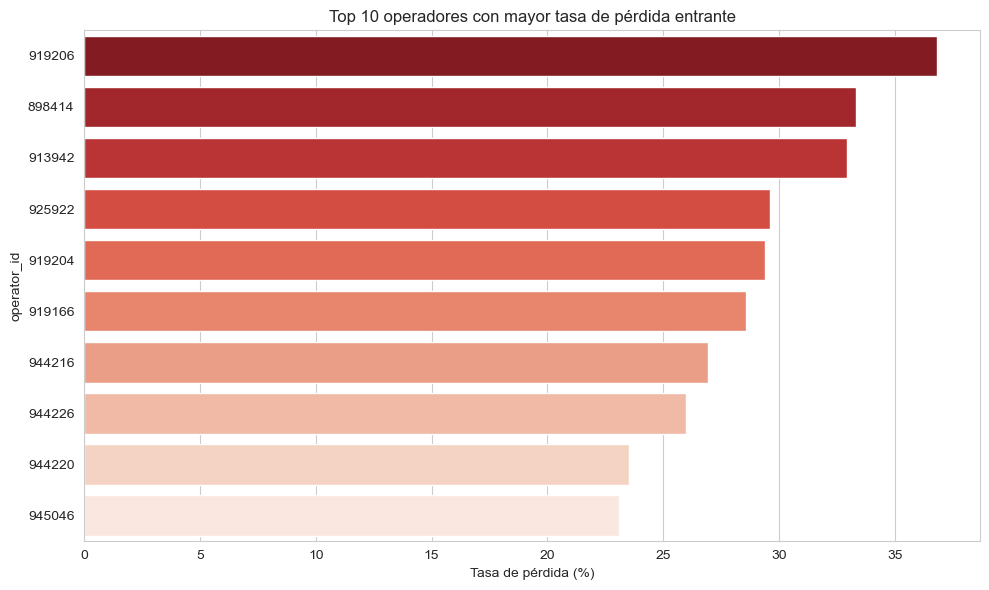

In [19]:
top_missed = ops_metrics[ops_metrics['total_in_calls'] > 10].nlargest(10, 'missed_rate_in')
plt.figure(figsize=(10,6))
sns.barplot(data=top_missed, x='missed_rate_in', y='operator_id', hue='operator_id', palette='Reds_r', legend=False)
plt.title('Top 10 operadores con mayor tasa de pérdida entrante')
plt.xlabel('Tasa de pérdida (%)')
plt.tight_layout()
plt.show()

## 5.2 Distribución de perfiles de operadores

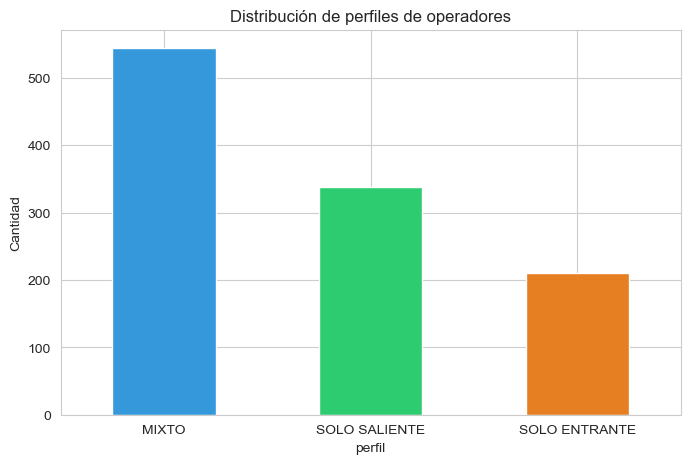

In [20]:
perfil_counts = ops_metrics['perfil'].value_counts()
plt.figure(figsize=(8,5))
perfil_counts.plot(kind='bar', color=['#3498db','#2ecc71','#e67e22'])
plt.title('Distribución de perfiles de operadores')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

## 5.3 Operadores ineficaces por perfil

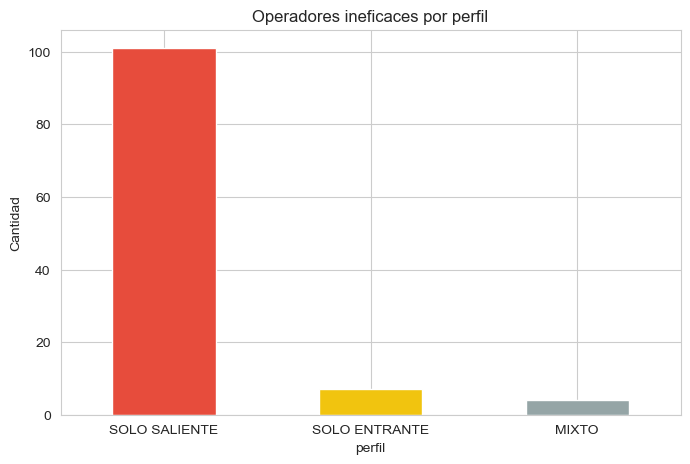

In [22]:
inef_por_perfil = ops_metrics[ops_metrics['is_inefficient']]['perfil'].value_counts()
plt.figure(figsize=(8,5))
inef_por_perfil.plot(kind='bar', color=['#e74c3c','#f1c40f','#95a5a6'])
plt.title('Operadores ineficaces por perfil')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

## VI. Dashboards y Visualizaciones Clave

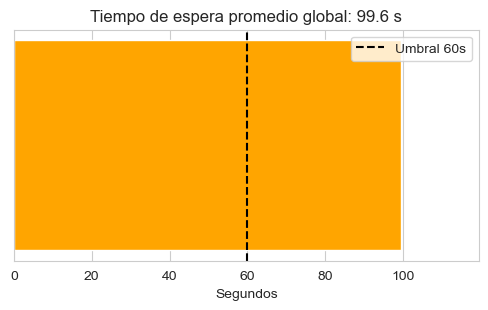

Porcentaje de registros con operador válido (trazabilidad): 84.8%
 ALERTA: Trazabilidad baja (<90%). Revisar sistema de logging.


In [23]:
# 1. Indicador global de tiempo de espera promedio (solo entrantes atendidas)
atendidas = telecom_clean[(telecom_clean['direction'] == 'in') & (~telecom_clean['is_missed_call'])]
avg_wait_global = atendidas['wait_time'].mean()
umbral_espera = 60

# Gráfico de gauge simple con matplotlib
fig, ax = plt.subplots(figsize=(6,3))
gauge_colors = ['green' if avg_wait_global <= umbral_espera else 'orange' if avg_wait_global <= 120 else 'red']
ax.barh([0], avg_wait_global, color=gauge_colors[0], height=0.5)
ax.axvline(x=umbral_espera, color='black', linestyle='--', label=f'Umbral {umbral_espera}s')
ax.set_xlim(0, max(avg_wait_global*1.2, umbral_espera*1.2))
ax.set_yticks([])
ax.set_xlabel('Segundos')
ax.set_title(f'Tiempo de espera promedio global: {avg_wait_global:.1f} s')
ax.legend()
plt.show()

# 2. Indicador de trazabilidad
total_registros = len(telecom_clean)
trazables = telecom_clean[~telecom_clean['operator_id'].isin(['unknown','no_registered'])]
pct_trazabilidad = len(trazables) / total_registros * 100
print(f"Porcentaje de registros con operador válido (trazabilidad): {pct_trazabilidad:.1f}%")
if pct_trazabilidad < 90:
    print(" ALERTA: Trazabilidad baja (<90%). Revisar sistema de logging.")

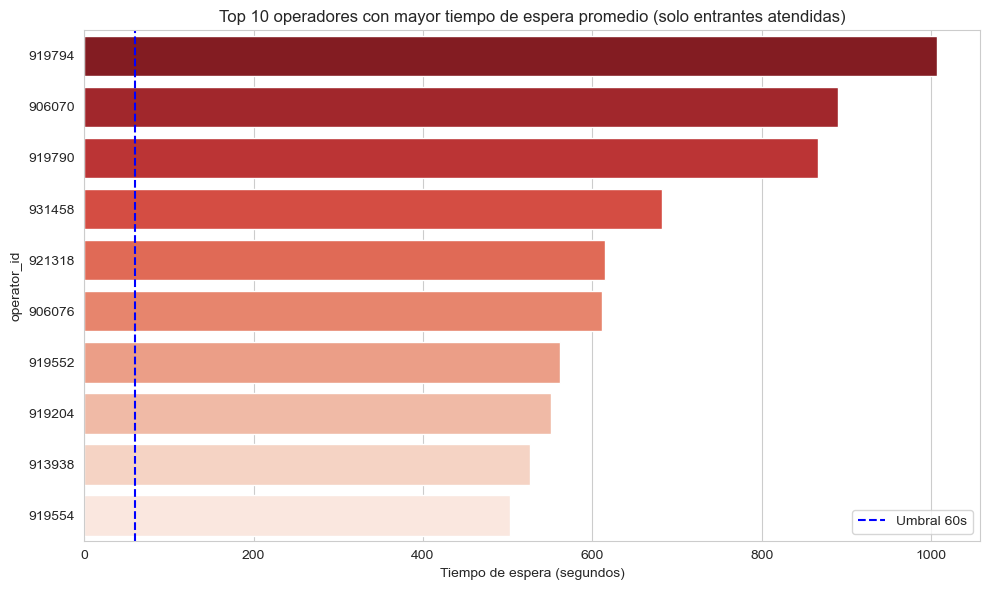

In [24]:
# Top 10 operadores con mayor tiempo de espera (solo entrantes, excluyendo perdidas)
top_wait = ops_metrics[ops_metrics['avg_wait_time'] > 0].nlargest(10, 'avg_wait_time')
plt.figure(figsize=(10,6))
sns.barplot(data=top_wait, x='avg_wait_time', y='operator_id', hue='operator_id', palette='Reds_r', legend=False)
plt.title('Top 10 operadores con mayor tiempo de espera promedio (solo entrantes atendidas)')
plt.xlabel('Tiempo de espera (segundos)')
plt.axvline(x=umbral_wait_time, color='blue', linestyle='--', label=f'Umbral {umbral_wait_time}s')
plt.legend()
plt.tight_layout()
plt.show()

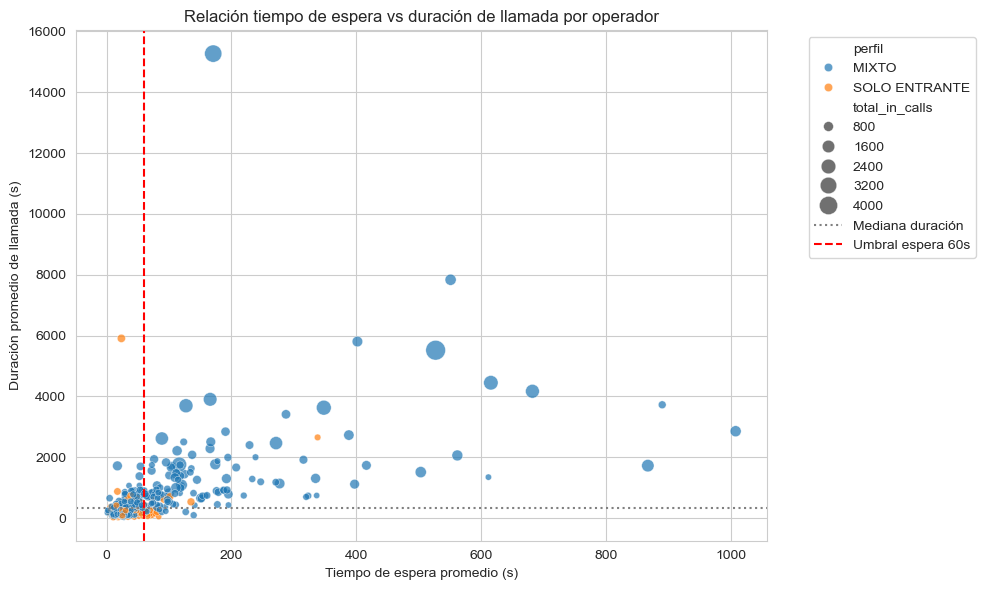

In [25]:
# Agregar duración promedio por operador (solo entrantes atendidas)
df_duracion_op = atendidas.groupby('operator_id')['call_duration'].mean().reset_index()
df_duracion_op.columns = ['operator_id', 'avg_call_duration']
ops_metrics_with_dur = ops_metrics.merge(df_duracion_op, on='operator_id', how='left')

# Filtrar operadores con al menos 10 llamadas entrantes para robustez
ops_filt = ops_metrics_with_dur[ops_metrics_with_dur['total_in_calls'] >= 10]

plt.figure(figsize=(10,6))
scatter = sns.scatterplot(data=ops_filt, x='avg_wait_time', y='avg_call_duration', 
                          hue='perfil', size='total_in_calls', sizes=(20,200), alpha=0.7)
plt.axhline(y=ops_filt['avg_call_duration'].median(), color='gray', linestyle=':', label='Mediana duración')
plt.axvline(x=umbral_wait_time, color='red', linestyle='--', label=f'Umbral espera {umbral_wait_time}s')
plt.title('Relación tiempo de espera vs duración de llamada por operador')
plt.xlabel('Tiempo de espera promedio (s)')
plt.ylabel('Duración promedio de llamada (s)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

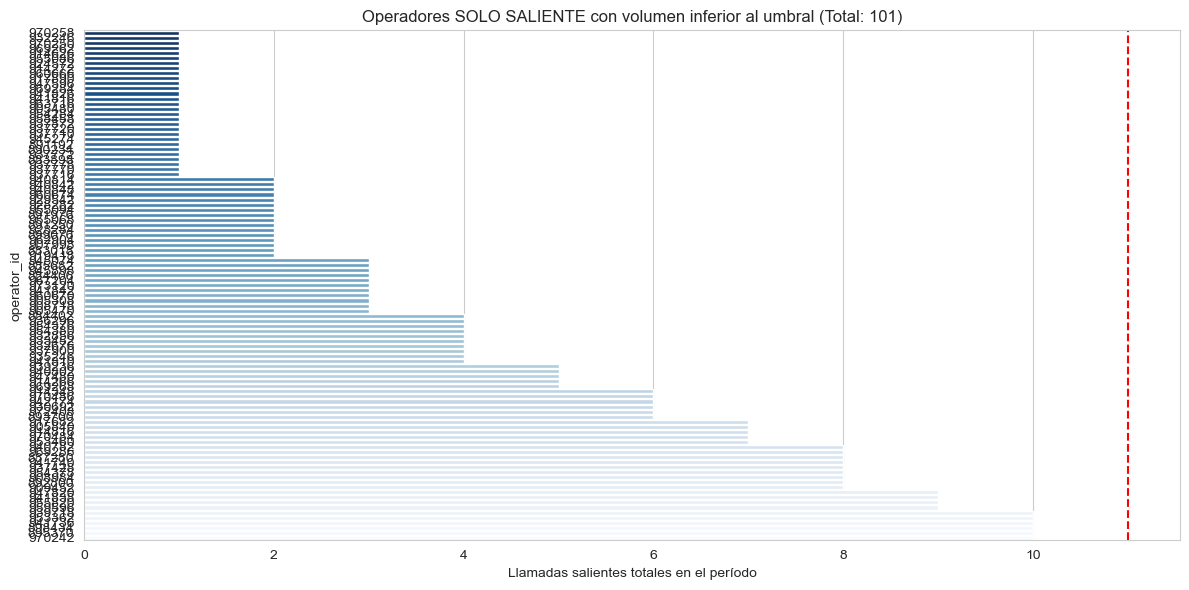

In [26]:
# Gráfico de barras para operadores SOLO SALIENTE con bajo volumen
solo_saliente = ops_metrics[ops_metrics['perfil'] == 'SOLO SALIENTE']
low_outbound = solo_saliente[solo_saliente['total_out_calls'] < umbral_out_calls].sort_values('total_out_calls')

if len(low_outbound) > 0:
    plt.figure(figsize=(12,6))
    sns.barplot(data=low_outbound, x='total_out_calls', y='operator_id', hue='operator_id', palette='Blues_r', legend=False)
    plt.axvline(x=umbral_out_calls, color='red', linestyle='--', label=f'Umbral mínimo ({umbral_out_calls:.0f} llamadas)')
    plt.title(f'Operadores SOLO SALIENTE con volumen inferior al umbral (Total: {len(low_outbound)})')
    plt.xlabel('Llamadas salientes totales en el período')
    plt.tight_layout()
    plt.show()
else:
    print("No hay operadores solo salientes con volumen bajo el umbral.")

# VII: Conclusiones, Recomendaciones y Limitaciones

## 7.1 Hallazgos principales

1. **Clasificación integral de operadores**: Aplicando la metodología que combina calidad en la atención (tasa de pérdida y tiempo de espera) y productividad saliente (volumen de llamadas), se obtuvieron los siguientes resultados:
   - **692 operadores (63.4%)** son eficientes en ambos aspectos.
   - **204 (18.7%)** requieren mejorar la atención (alta tasa de pérdida o tiempo de espera elevado).
   - **193 (17.7%)** requieren mejorar la productividad (bajo volumen de llamadas salientes).
   - **3 (0.3%)** son críticos, con problemas graves tanto en atención como en productividad.

2. **Perfil de ineficacia predominante**: El 90% de los operadores con problemas de productividad pertenecen al perfil **SOLO SALIENTE**, lo que indica que la principal debilidad operativa no es la mala atención al cliente, sino la baja actividad en campañas salientes.

3. **Operadores mixtos críticos**: Los tres operadores clasificados como críticos (919206, 919204, 919164) presentan valores extremos: tasas de pérdida del 21‑37%, tiempos de espera de 287‑551 segundos y volumen saliente casi nulo (1‑10 llamadas). Requieren intervención prioritaria.

4. **Operadores solo entrantes con problemas de atención**: 7 operadores (3.3% de los solo entrantes) presentan tiempos de espera de hasta 135 segundos, aunque sus tasas de pérdida son moderadas (2‑14%). Atienden casi todas las llamadas, pero el cliente espera demasiado.

5. **Problema de trazabilidad**: 7,456 registros (15.2%) corresponden a llamadas sin operador asignado (`unknown` y `no_registered`), acumulando 138 horas de conversación sin dueño. Esto impide evaluar la eficiencia de una parte significativa del sistema.

6. **Pruebas de hipótesis**:
   - **H1 (correlación entre tiempo de espera y llamadas perdidas)**: Correlación negativa muy débil (ρ = -0.089, p < 0.001). No existe relación práctica relevante.
   - **H2 (duración de llamadas externas vs internas)**: Diferencia altamente significativa (p < 0.001). Las llamadas externas duran el doble que las internas.
   - **H3 (correlación entre volumen de llamadas salientes y tasa de pérdida entrante)**: Correlación positiva baja (ρ = 0.281, p < 0.001). Mayor actividad saliente se asocia a ligeramente mayor pérdida entrante.
   - **H4 (diferencia de tiempo de espera entre perfiles solo entrantes y mixtos)**: Los operadores mixtos tienen tiempos de espera significativamente mayores (t = -6.35, p < 0.001).
   - **H5 (correlación entre tiempo de espera y duración de la llamada, solo atendidas)**: Correlación positiva moderada (ρ = 0.697, p < 0.001). A mayor espera, conversaciones más largas.

## 7.2 Operadores críticos a intervenir

| ID Operador | Perfil                     | Tasa pérdida (%) | Tiempo espera (s) | Llamadas out | Acción sugerida |
|-------------|----------------------------|------------------|-------------------|--------------|-----------------|
| 919206      | CRÍTICO (ambos problemas)  | 36.8             | 388               | 1            | Evaluación inmediata y plan de mejora intensivo |
| 919204      | CRÍTICO (ambos problemas)  | 29.4             | 551               | 9            | Evaluación inmediata y plan de mejora intensivo |
| 919164      | CRÍTICO (ambos problemas)  | 21.4             | 287               | 10           | Evaluación inmediata y plan de mejora intensivo |
| 909134      | MEJORAR ATENCIÓN           | 1.5              | 107               | 5            | Capacitación en reducción de espera |
| 911142      | MEJORAR ATENCIÓN           | 14.3             | 66                | 0            | Optimizar tiempos de respuesta |
| 948286      | MEJORAR ATENCIÓN           | 10.8             | 135               | 0            | Reforzar eficiencia en atención |
| 887280      | MEJORAR PRODUCTIVIDAD      | 0.0              | 0                 | 8            | Reasignar o evaluar carga de trabajo |
| 884402      | MEJORAR PRODUCTIVIDAD      | 0.0              | 0                 | 4            | Reasignar o capacitar |

## 7.3 Recomendaciones

1. **Mejorar la trazabilidad**  
   - Auditar el sistema de logging para eliminar los valores `unknown` y `no_registered`.  
   - Implementar una regla de negocio que asigne automáticamente un operador a cada llamada atendida.

2. **Optimizar la atención entrante**  
   - Reducir el tiempo de espera a menos de 60 segundos.  
   - Reforzar personal en horas pico (martes, miércoles y jueves).  
   - Implementar un sistema de colas inteligente según disponibilidad y rendimiento histórico.

3. **Revisar la productividad saliente**  
   - Establecer un mínimo de llamadas salientes semanales (ej. 20) y monitorear el cumplimiento.  
   - Reasignar a operadores con volumen muy bajo (menos de 11 llamadas en todo el período).

4. **Capacitación y supervisión**  
   - Capacitar a los operadores mixtos con altas tasas de pérdida y tiempos de espera.  
   - Implementar un tablero de control semanal con los KPIs definidos.

## 7.4 Limitaciones del estudio

- **Trazabilidad**: El 15.2% de los registros (7,456) fueron excluidos por falta de operador asignado (`unknown` y `no_registered`), lo que puede subestimar o sesgar la identificación de operadores ineficaces.  
- **Outliers**: Se consideraron errores técnicos las llamadas con duración > 1425 segundos y se filtraron para los cálculos de promedios.  
- **Clasificación de ineficacia en salientes**: Solo se usó el volumen de llamadas, sin considerar la calidad o el resultado de esas llamadas (ej. ventas concretadas).  
- **Imposibilidad de análisis temporales**: La columna `date` representa la fecha de extracción de los datos, no la fecha real de la llamada. Esto invalida cualquier análisis que requiera el día de la semana o tendencias temporales (por ejemplo, la hipótesis original H1). Se recomienda corregir la fuente de datos para futuros estudios.